In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS=set(stopwords.words('english'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import files

uploaded = files.upload()

import pathlib

relative_path = pathlib.Path('amazon_alexa.tsv')
absolute_path = relative_path.resolve()

print(f"Is '{absolute_path}' file exist: {'yes' if absolute_path.exists() else 'no'}")


Saving amazon_alexa.tsv to amazon_alexa.tsv
Is '/content/amazon_alexa.tsv' file exist: yes


In [ ]:
import pandas as pd

# Read the TSV file
file_path = 'amazon_alexa.tsv'
data = pd.read_csv(file_path, sep='\t',encoding='ISO-8859-1')

# Display the first few rows to check the data
print(data.head())
print(f"Dataset shape: {data.shape}")


   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18     Walnut Finish   
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  
Dataset shape: (3150, 5)


In [ ]:
data.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [ ]:
#getting the record where verified_reviews is null
data[data['verified_reviews'].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [ ]:
#drop rows with null records
data.dropna(inplace=True)

In [ ]:
print(f"Dataset shape after dropping null values: {data.shape}")

Dataset shape after dropping null values: (3149, 5)


In [ ]:
#creating a new column 'length' that will contain the length of the string in the verified_reviews' column

data['length'] = data['verified_reviews'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)


In [ ]:
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,193
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [ ]:
#randomly checking for 10 th record

print(f"'verified_reviews' column values: {data.iloc[10]['verified_reviews']}")
print(f"Length of review: {len(data.iloc[10]['verified_reviews'])}") #length of review using len()
print(f"'length' column value: {data.iloc[10]['length']}") #value of the column length

'verified_reviews' column values: I sent it to my 85 year old Dad, and he talks to it constantly.
Length of review: 63
'length' column value: 63


In [ ]:
#distinct values of 'rating' and its count

print(f"Rating value count: \n{data['rating'].value_counts()}")

Rating value count: 
rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64


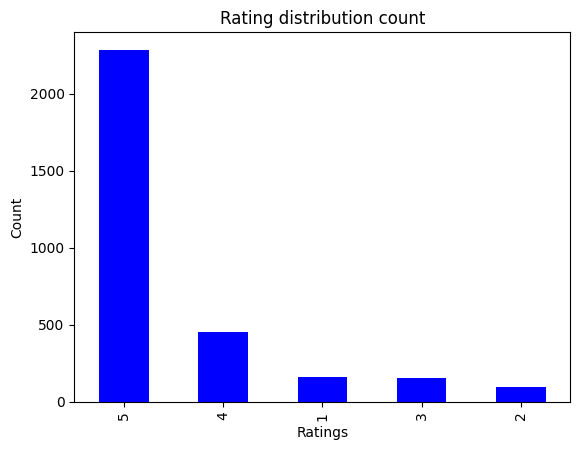

In [ ]:
data['rating'].value_counts().plot.bar(color='blue')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()


In [ ]:
#Finding the percentage distribution of each rating-we'll divide the number of records for each rating by total number of records

print(f"Rating value count- percentage distribution: \n{round(data['rating'].value_counts()/data.shape[0]*100,2)}")


Rating value count- percentage distribution: 
rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


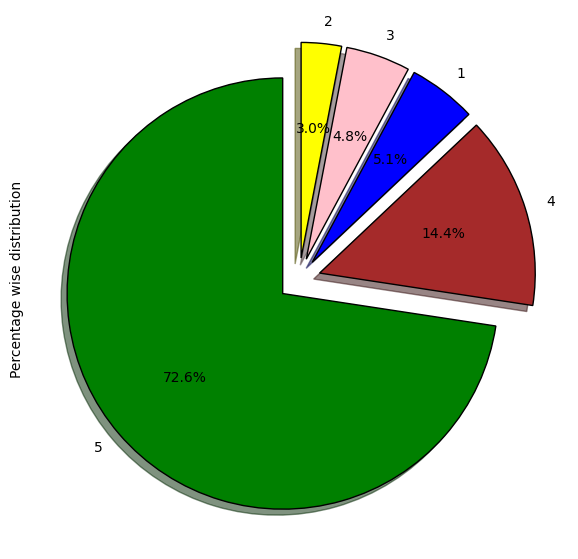

In [ ]:
fig=plt.figure(figsize=(7,7))
colors=('green','brown','blue','pink','yellow')
wp={'linewidth':1,'edgecolor':'black'}
tags=data['rating'].value_counts()/data.shape[0]
explode=(0.1,0.1,0.1,0.1,0.1)
tags.plot(kind='pie',autopct="%1.1f%%",shadow=True,colors=colors,startangle=90,wedgeprops=wp,explode=explode,label='Percentage wise distribution')
from io import BytesIO
graph=BytesIO()
fig.savefig(graph,format="png")

Analysing the feedback column

In [ ]:
#distinct values of feedback and its count
print(f"Feedback value count: \n{data['feedback'].value_counts()}")


Feedback value count: 
feedback
1    2893
0     256
Name: count, dtype: int64


In [ ]:
#There are two distinct values of feedback present- 0 and 1. Let's see what kind of review each value corresponds to

In [ ]:
#extracting the verified_reviews value for one record with feedback=0
#extract first record
review_0=data[data['feedback'] == 0].iloc[1]['verified_reviews']
print(review_0)

Sound is terrible if u want good music too get a bose


In [ ]:
#extracting verified_reviews value for one record with feedback=1
review_1=data[data['feedback']==1].iloc[1]['verified_reviews']
print(review_1)

Loved it!


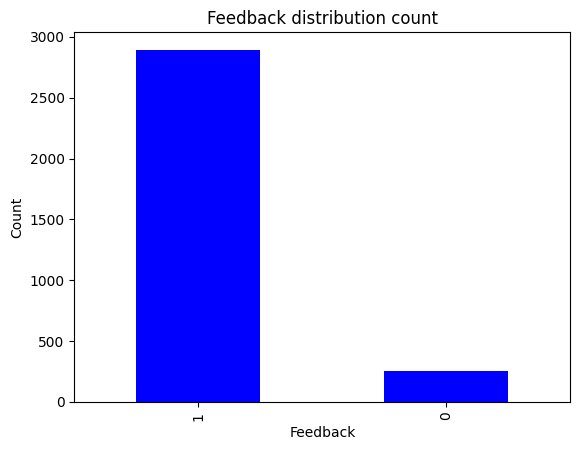

In [ ]:
#Bar graph to visualise the total counts of each feedback

data['feedback'].value_counts().plot.bar(color='blue')
plt.title('Feedback distribution count')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [ ]:
#finding the percentage distribution of each feedback- we'll divide the number of records for each feedback by total number of records
print(f"Feedback value count- percentage distribution: \n{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

Feedback value count- percentage distribution: 
feedback
1    91.87
0     8.13
Name: count, dtype: float64


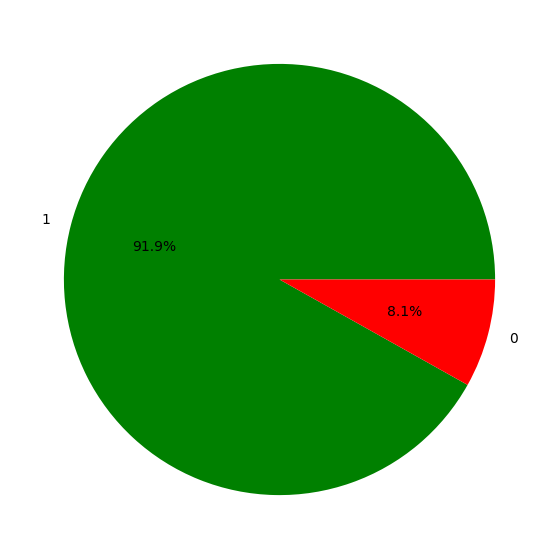

In [ ]:
fig=plt.figure(figsize=(7,7))
colors=('green''brown')
plt.pie(data['feedback'].value_counts(),labels=data['feedback'].value_counts().index,autopct="%1.1f%%",colors=colors)
plt.show()

In [ ]:
#rating values of different feedbacks
data[data['feedback']==0]['rating'].value_counts()

,count
rating,
1,161
2,95


In [ ]:
data[data['feedback']==1]['rating'].value_counts()

,count
rating,
5,2286
4,455
3,152


Analyzing variation column

In [ ]:
print(f"Variation value count: \n{data['variation'].value_counts()}")

Variation value count: 
variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
White                            90
Sandstone Fabric                 90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     8
Walnut Finish                     1
Name: count, dtype: int64


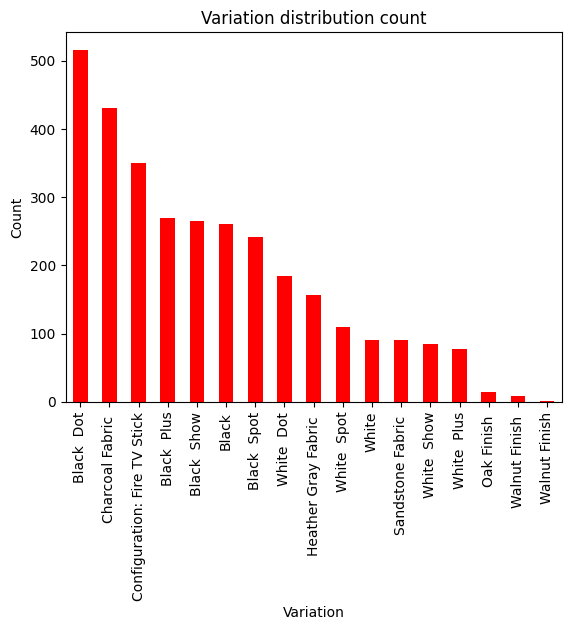

In [ ]:
#bar graph to visualize the total counts of each variation

data['variation'].value_counts().plot.bar(color='red')
plt.title('Variation distribution count')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.show()

In [ ]:
#finding percentage distribution of variation
print(f"Variation value count- percentage distribution: \n{round(data['variation'].value_counts()/data.shape[0]*100,2)}")

Variation value count- percentage distribution: 
variation
Black  Dot                      16.39
Charcoal Fabric                 13.66
Configuration: Fire TV Stick    11.11
Black  Plus                      8.57
Black  Show                      8.42
Black                            8.29
Black  Spot                      7.65
White  Dot                       5.84
Heather Gray Fabric              4.99
White  Spot                      3.46
White                            2.86
Sandstone Fabric                 2.86
White  Show                      2.70
White  Plus                      2.48
Oak Finish                       0.44
Walnut Finish                    0.25
Walnut Finish                    0.03
Name: count, dtype: float64


In [ ]:
data.groupby('variation')['rating'].mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x7e737e2c98a0>>

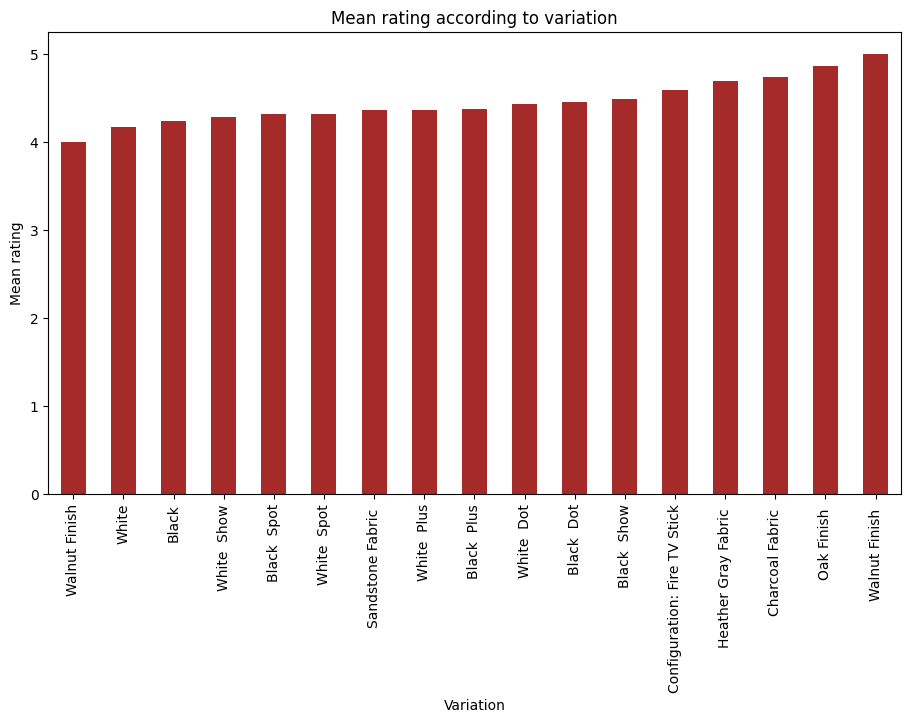

In [ ]:
data.groupby('variation')['rating'].mean().sort_values().plot.bar(color='brown',figsize=(11,6))
plt.title("Mean rating according to variation")
plt.xlabel('Variation')
plt.ylabel('Mean rating')
plt.show()

analyzing verified reviews

In [ ]:
data['length'].describe()

,length
count,3149.000000
mean,132.102890
std,182.113976
min,1.000000
25%,30.000000
50%,74.000000
75%,165.000000
max,2851.000000


[Text(0.5, 1.0, 'Distribution of length of review')]

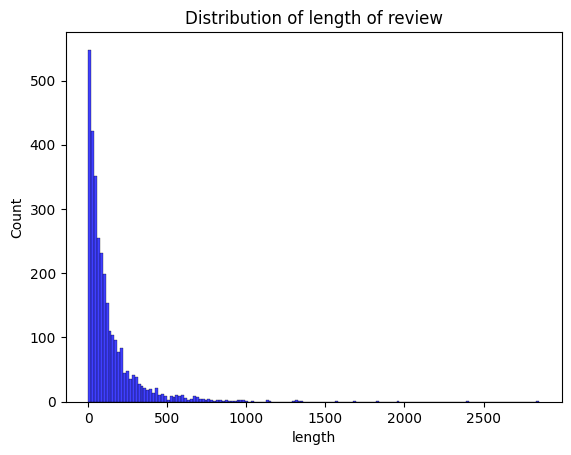

In [ ]:
sns.histplot(data['length'],color='blue').set(title='Distribution of length of review')

Length analysis when feedback=0

[Text(0.5, 1.0, 'Distribution of length of review when feedback=0')]

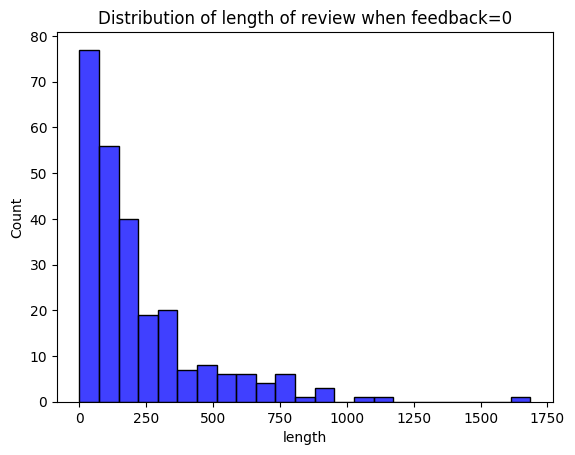

In [ ]:
sns.histplot(data[data['feedback']==0]['length'],color='blue').set(title='Distribution of length of review when feedback=0')

[Text(0.5, 1.0, 'Distribution of length of review when feedback=1')]

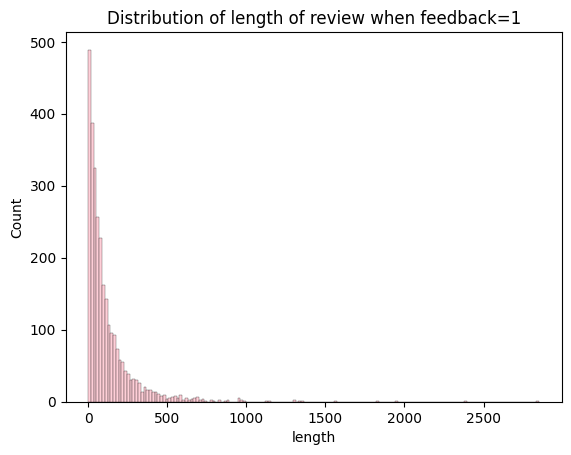

In [ ]:
sns.histplot(data[data['feedback']==1]['length'],color='pink').set(title='Distribution of length of review when feedback=1')

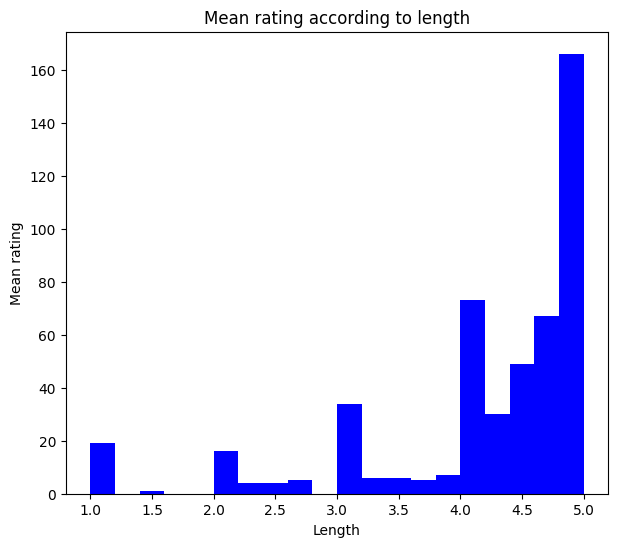

In [ ]:
data.groupby('length')['rating'].mean().plot.hist(color='blue',figsize=(7,6),bins=20)
plt.title("Mean rating according to length")
plt.xlabel('Length')
plt.ylabel('Mean rating')
plt.show()

In [ ]:
cv=CountVectorizer()
X=cv.fit_transform(data['verified_reviews'])

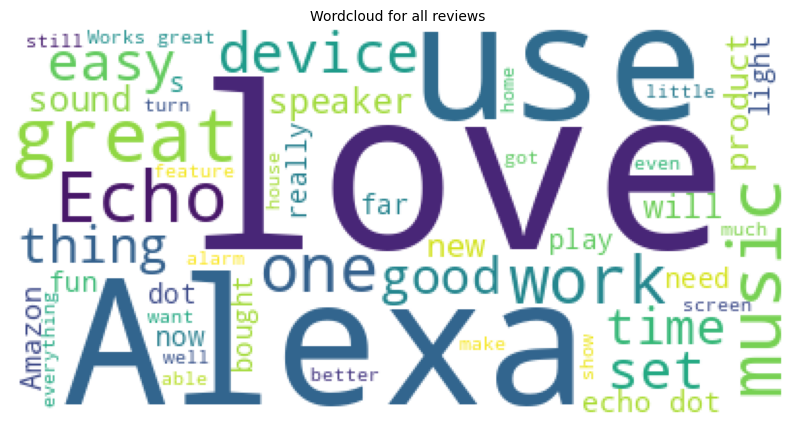

In [ ]:
# Combine all reviews
reviews = " ".join([review for review in data['verified_reviews']])

# Initialize wordcloud object
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(reviews))
plt.title('Wordcloud for all reviews', fontsize=10)
plt.axis('off')
plt.show()

In [ ]:
# Combine all reviews for each feedback category and splitting them into individual words
neg_reviews = " ".join([review for review in data[data['feedback'] == 0]['verified_reviews']])
neg_reviews = neg_reviews.lower().split()

pos_reviews = " ".join([review for review in data[data['feedback'] == 1]['verified_reviews']])
pos_reviews = pos_reviews.lower().split()

#Finding words from reviews which are present in that feedback category only
unique_negative = [x for x in neg_reviews if x not in pos_reviews]
unique_negative = " ".join(unique_negative)

unique_positive = [x for x in pos_reviews if x not in neg_reviews]
unique_positive = " ".join(unique_positive)

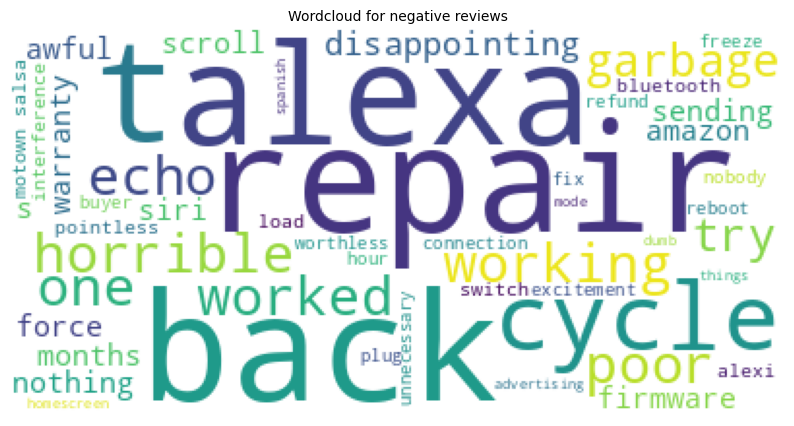

In [ ]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_negative))
plt.title('Wordcloud for negative reviews', fontsize=10)
plt.axis('off')
plt.show()

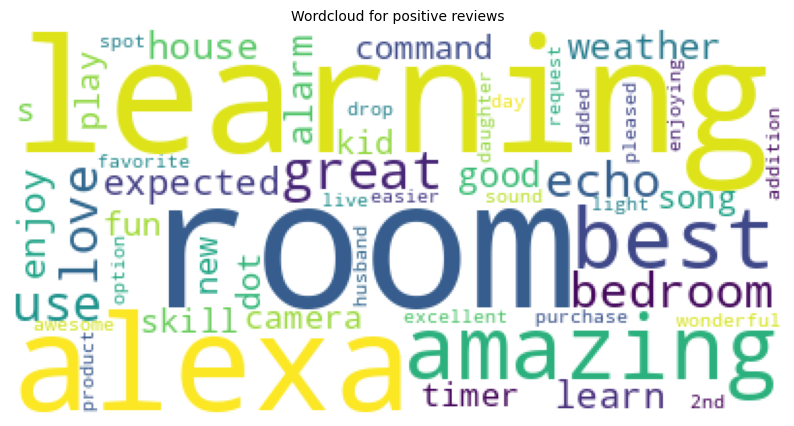

In [ ]:
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10,10))
plt.imshow(wc.generate(unique_positive))
plt.title('Wordcloud for positive reviews', fontsize=10)
plt.axis('off')
plt.show()

PREPROCESSING AND MODELLING

1. Replace any non-alphabet characters with a space

2. Convert to lower case and split into words

3. Iterate over the individual words and if it is not a stopword then add the stemmed form of the word to the corpus

In [ ]:
corpus=[]
stemmer=PorterStemmer()
for i in range(0,len(data)):
  review=re.sub('[^a-zA-Z]',' ',data.iloc[i]['verified_reviews'])
  review=review.lower()
  review=review.split()
  review=[stemmer.stem(word) for word in review if not word in STOPWORDS]
  review=' '.join(review)
  corpus.append(review)

cv=CountVectorizer(max_features =2500)

#sorting independent and dependent variables in X and Y



In [ ]:
cv=CountVectorizer(max_features =2500)
X=cv.fit_transform(corpus).toarray()
y=data['feedback'].values

In [ ]:
#start the count vectorizer
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

pickle.dump(cv,open('models/countVectorizer.pkl','wb'))

Checking the shape of X and y

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (3149, 2500)
y shape: (3149,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

print(f"X train: {X_train.shape}")
print(f"X test: {X_test.shape}")
print(f"y train: {y_train.shape}")
print(f"y test: {y_test.shape}")

X train: (2204, 2500)
X test: (945, 2500)
y train: (2204,)
y test: (945,)


In [ ]:
print(f"X train max values: {X_train.max()}")
print(f"X test max values: {X_test.max()}")


X train max values: 12
X test max values: 7


scaling X_train, X_test so that all values between 0 and 1

In [ ]:
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#saving the scaler model
pickle.dump(scaler,open('models/scaler.pkl','wb'))

Random forest

In [ ]:
#fitting scaled X_train and y_train on Random forest classifier
model_rf=RandomForestClassifier(n_estimators=100,criterion='entropy',random_state=0)
model_rf.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [ ]:
#Accuracy score on testing and training dataset
print(f"Training accuracy:{model_rf.score(X_train,y_train)}")
print(f"Testing accuracy:{model_rf.score(X_test,y_test)}")

Training accuracy:0.9941016333938294
Testing accuracy:0.9322751322751323


In [ ]:
y_preds=model_rf.predict(X_test)

In [ ]:
cm=confusion_matrix(y_test,y_preds)

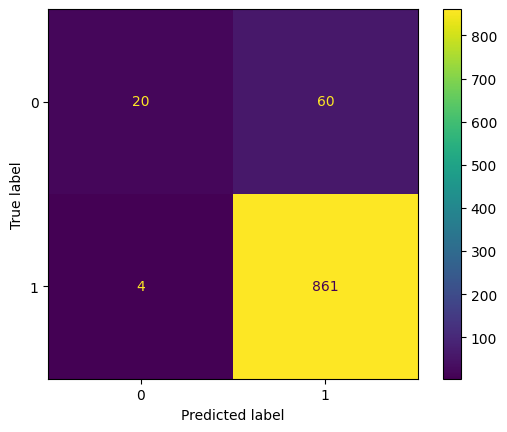

In [ ]:
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_rf.classes_)
cm_display.plot()
plt.show()

K fold validation

In [ ]:
accuracies=cross_val_score(estimator=model_rf,X=X_train,y=y_train,cv=10)

print(f"Mean accuracy: {accuracies.mean()}")
print(f"Standard deviation: {accuracies.std()}")

Accuracies: [0.92760181 0.94117647 0.93665158 0.93665158 0.95       0.95454545
 0.93181818 0.94545455 0.94545455 0.94090909]
Mean accuracy: 0.941026326614562
Standard deviation: 0.007783524232305964


Applying grid search to get optimal parameters on random forest


In [ ]:
params = {
    'bootstrap': [True],
    'max_depth': [80, 100],
    'min_samples_split': [8, 12],
    'n_estimators': [100, 300]
}

Xgboost

In [ ]:
model_xgb=XGBClassifier()
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
#accuracy score
print(f"Training accuracy:{model_xgb.score(X_train,y_train)}")
print(f"Testing accuracy:{model_xgb.score(X_test,y_test)}")

Training accuracy:0.9773139745916516
Testing accuracy:0.9238095238095239


In [ ]:
y_preds=model_xgb.predict(X_test)

In [ ]:
cm=confusion_matrix(y_test,y_preds)
print(cm)

[[ 24  56]
 [ 16 849]]


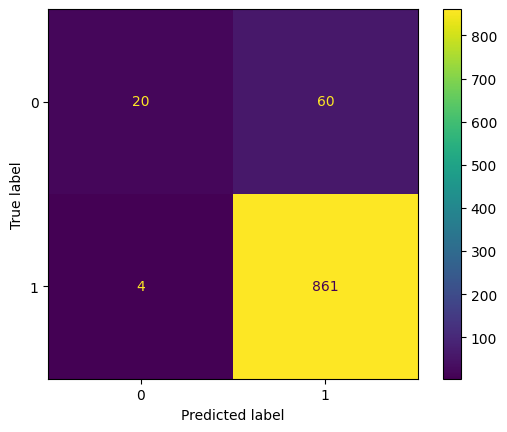

In [ ]:
cm_dispaly=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_xgb.classes_)
cm_display.plot()
plt.show()

In [ ]:
#saving the XGBoost Classifier
pickle.dump(model_xgb,open('models/xgboost.pkl','wb'))